# Morph Metrics

| Short | Meaning |
|-------|---------|
| file | Source file name |
| lang | ISO 639-3 code |
| word_* | Metrics on whole word types |
| morph_* | Metrics on morph types |
| compounding_index | Per-word avg roots/morphs |
| affix_deviation | Per-word avg (pref-suf)/min(pref,suf) |
| root_entropy | Entropy over root types |
| affix_entropy | Entropy over affix types |
| prefix_entropy | Entropy over prefix types |
| suffix_entropy | Entropy over suffix types |

In [44]:
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parents[1]
df = pd.read_csv(ROOT / "results" / "3_analyze" / "total_results.csv")

# Typology encoding: words → numbers
TYPOLOGY_MAP = {"Isolating": 0, "Agglutinative": 1, "Fusional": 2, "Introflexive": 3, "Polysynthetic": 4}
df["typology_num"] = df["typology"].map(TYPOLOGY_MAP)

# Script type encoding: words → numbers
SCRIPT_TYPE_MAP = {"alphabet": 0, "abjad": 1, "abugida": 2, "ethiopic": 3, "syllabary": 4, "logographic": 5}
df["script_type_num"] = df["script_type"].map(SCRIPT_TYPE_MAP)

# Segmented subset (rows with morph data)
dfm = df.dropna(subset=["morph_entropy"]).copy()
dfm["label"] = dfm["lang"] + "_" + dfm["segmentor"]

print(f"Total: {len(df)} rows, Segmented: {len(dfm)} rows")
dfm.head(10)

Total: 175 rows, Segmented: 41 rows


,lang,script,script_type,segmentor,language_name,family,genus,typology,dominant_script_pct,original_token_count,...,affix_type_entropy,prefix_type_entropy,suffix_type_entropy,root_count,affix_count,prefix_count,suffix_count,typology_num,script_type_num,label
13,bel,Cyrl,alphabet,Slounik,Belorussian,Indo-European,Slavic,Fusional,94.85,131123017,...,7.534565,5.521506,6.690371,49265.0,1558.0,621.0,928.0,2,0,bel_Slounik
14,ben,Beng,abugida,kcis,Bengali,Indo-European,Indic,Fusional,97.78,66691412,...,5.602736,5.039631,5.553755,80778.0,359.0,90.0,351.0,2,2,ben_kcis
21,cat,Latn,alphabet,Morphynet,Catalan,Indo-European,Romance,Fusional,99.72,519947538,...,3.649320,4.393258,3.100677,28787.0,214.0,75.0,164.0,2,0,cat_Morphynet
23,ces,Latn,alphabet,SlavickovaDict,Czech,Indo-European,Slavic,Fusional,99.91,1639474654,...,7.385669,5.905146,7.076963,35657.0,1487.0,750.0,1001.0,2,0,ces_SlavickovaDict
31,deu,Latn,alphabet,CELEX,German,Indo-European,Germanic,Fusional,99.93,9286535605,...,7.909091,7.546543,7.546844,54861.0,2082.0,998.0,1552.0,2,0,deu_CELEX
32,deu,Latn,alphabet,MorphoChallenge,German,Indo-European,Germanic,Fusional,99.93,9286535605,...,7.876884,7.460778,7.132424,53890.0,2389.0,1172.0,1573.0,2,0,deu_MorphoChallenge
35,ell,Grek,alphabet,GreekAnnotatedDictionary,Greek (Modern),Indo-European,Greek,Fusional,88.01,703548410,...,5.767038,4.064525,5.561238,40940.0,321.0,71.0,278.0,2,0,ell_GreekAnnotatedDictionary
36,eng,Latn,alphabet,MorphoLex,English,Indo-European,Germanic,Isolating,96.58,21496075402,...,5.519216,5.398449,4.903011,14289.0,349.0,143.0,285.0,0,0,eng_MorphoLex
41,fas,Arab,abjad,PerSegLex,Persian,Indo-European,Iranian,Isolating,96.57,1268906100,...,5.567730,5.538557,4.834397,20316.0,293.0,171.0,232.0,0,1,fas_PerSegLex
43,fin,Latn,alphabet,MorphoChallenge,Finnish,Uralic,Finnic,Agglutinative,99.96,660781477,...,8.822354,8.833460,7.211370,195604.0,4211.0,2008.0,2333.0,1,0,fin_MorphoChallenge


In [45]:
print("=== Morph TTR: 5 highest ===")
print(dfm.nlargest(5, "morph_ttr")[["label", "morph_ttr"]].to_string(index=False))
print("\n=== Morph TTR: 5 lowest ===")
print(dfm.nsmallest(5, "morph_ttr")[["label", "morph_ttr"]].to_string(index=False))

print("\n=== Morph entropy: 5 highest ===")
print(dfm.nlargest(5, "morph_entropy")[["label", "morph_entropy"]].to_string(index=False))
print("\n=== Morph entropy: 5 lowest ===")
print(dfm.nsmallest(5, "morph_entropy")[["label", "morph_entropy"]].to_string(index=False))

=== Morph TTR: 5 highest ===
              label  morph_ttr
        zul_Sadilar   0.459259
           mal_kcis   0.321683
      tgk_Uniparser   0.109314
fin_MorphoChallenge   0.097118
     uig_thuuymorph   0.095773

=== Morph TTR: 5 lowest ===
               label  morph_ttr
         nso_Sadilar   0.004448
         tso_Sadilar   0.006310
         spa_Albalba   0.006626
            hin_kcis   0.008510
rus_KuznetsEfremDict   0.010309

=== Morph entropy: 5 highest ===
         label  morph_entropy
 pol_Morphynet      11.687914
uig_thuuymorph      11.368893
 hbs_Morphynet      11.356306
      mal_kcis      10.699090
 tgk_Uniparser      10.476860

=== Morph entropy: 5 lowest ===
      label  morph_entropy
nso_Sadilar       7.296523
tso_Sadilar       7.875264
tsn_Sadilar       8.108816
swa_LDC_RLP       8.113760
sot_Sadilar       8.189559


In [46]:
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.insert(0, str(ROOT / "notebooks" / "scripts"))
import graph_export
import lang_markers as lm
from matplotlib.lines import Line2D

dfm["color"] = dfm.apply(lm.get_color, axis=1)
dfm["is_morphynet"] = dfm["segmentor"] == "Morphynet"
dfm_main = dfm[~dfm["is_morphynet"]]
dfm_morph = dfm[dfm["is_morphynet"]]

graph_export: saved morph_word_entropy.pdf


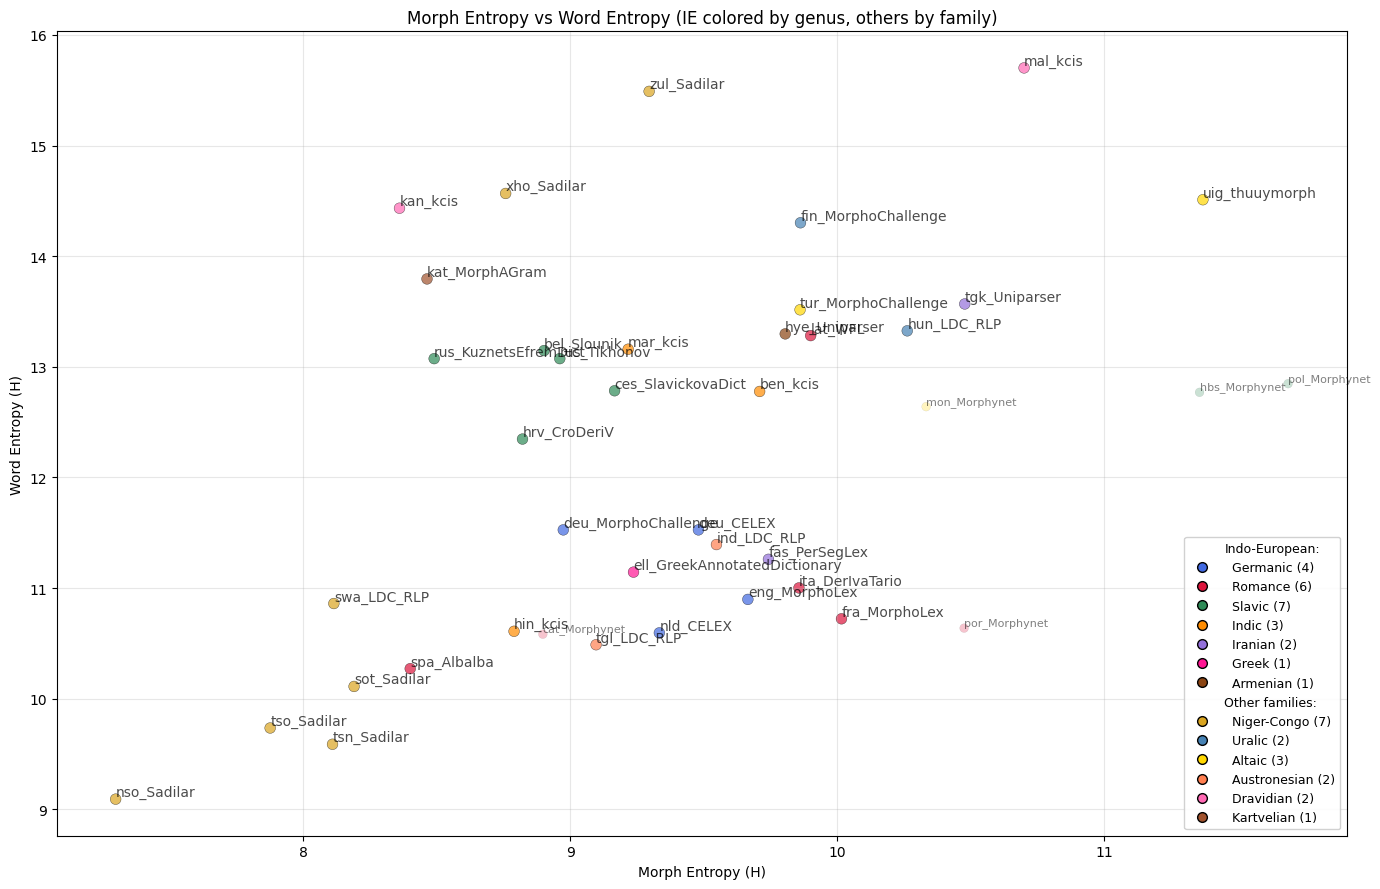

In [47]:
# Morph Entropy vs Word Entropy
fig, ax = plt.subplots(figsize=(14, 9))

ax.scatter(dfm_main["morph_entropy"], dfm_main["word_entropy"], s=60, alpha=0.7,
           c=dfm_main["color"], edgecolors="k", linewidths=0.3)
ax.scatter(dfm_morph["morph_entropy"], dfm_morph["word_entropy"], s=40, alpha=0.25,
           c=dfm_morph["color"], edgecolors="k", linewidths=0.15)

for _, row in dfm_main.iterrows():
    ax.annotate(row["label"], (row["morph_entropy"], row["word_entropy"]),
                fontsize=10, alpha=0.7, ha="left", va="bottom")
for _, row in dfm_morph.iterrows():
    ax.annotate(row["label"], (row["morph_entropy"], row["word_entropy"]),
                fontsize=8, alpha=0.5, ha="left", va="bottom")

ax.set_xlabel("Morph Entropy (H)")
ax.set_ylabel("Word Entropy (H)")
ax.set_title("Morph Entropy vs Word Entropy (IE colored by genus, others by family)")
ax.grid(alpha=0.3)

handles = lm.build_color_legend(dfm, counts=True)
ax.legend(handles=handles, loc="lower right", fontsize=9, framealpha=0.9)

plt.tight_layout()
graph_export.save("morph_word_entropy", fig)
plt.show()

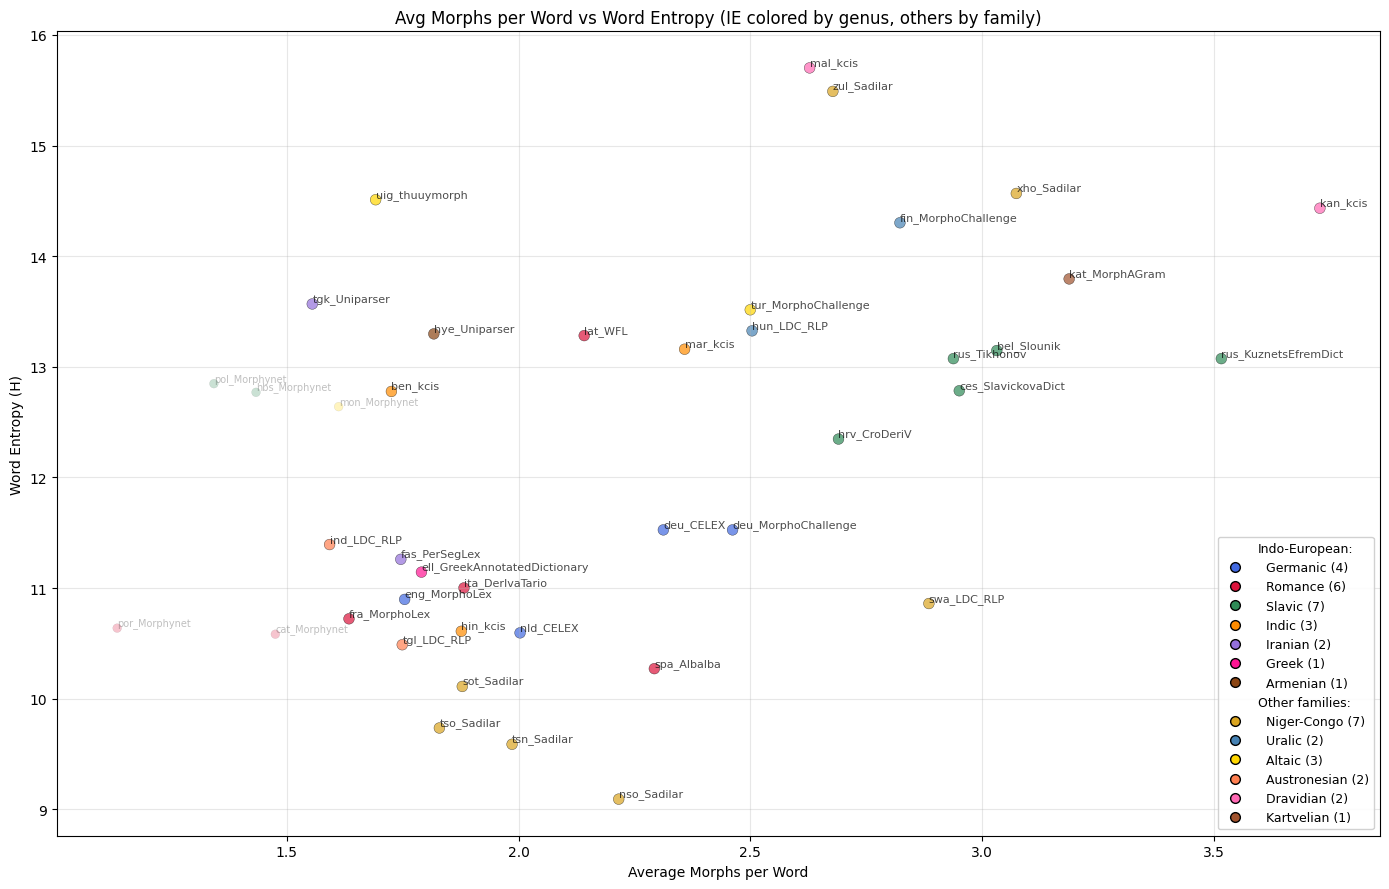

In [48]:
# Avg Morphs per Word vs Word Entropy
fig, ax = plt.subplots(figsize=(14, 9))

ax.scatter(dfm_main["avg_morphs_per_word"], dfm_main["word_entropy"], s=60, alpha=0.7,
           c=dfm_main["color"], edgecolors="k", linewidths=0.3)
ax.scatter(dfm_morph["avg_morphs_per_word"], dfm_morph["word_entropy"], s=40, alpha=0.25,
           c=dfm_morph["color"], edgecolors="k", linewidths=0.15)

for _, row in dfm_main.iterrows():
    ax.annotate(row["label"], (row["avg_morphs_per_word"], row["word_entropy"]),
                fontsize=8, alpha=0.7, ha="left", va="bottom")
for _, row in dfm_morph.iterrows():
    ax.annotate(row["label"], (row["avg_morphs_per_word"], row["word_entropy"]),
                fontsize=7, alpha=0.25, ha="left", va="bottom")

ax.set_xlabel("Average Morphs per Word")
ax.set_ylabel("Word Entropy (H)")
ax.set_title("Avg Morphs per Word vs Word Entropy (IE colored by genus, others by family)")
ax.grid(alpha=0.3)

handles = lm.build_color_legend(dfm, counts=True)
ax.legend(handles=handles, loc="lower right", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

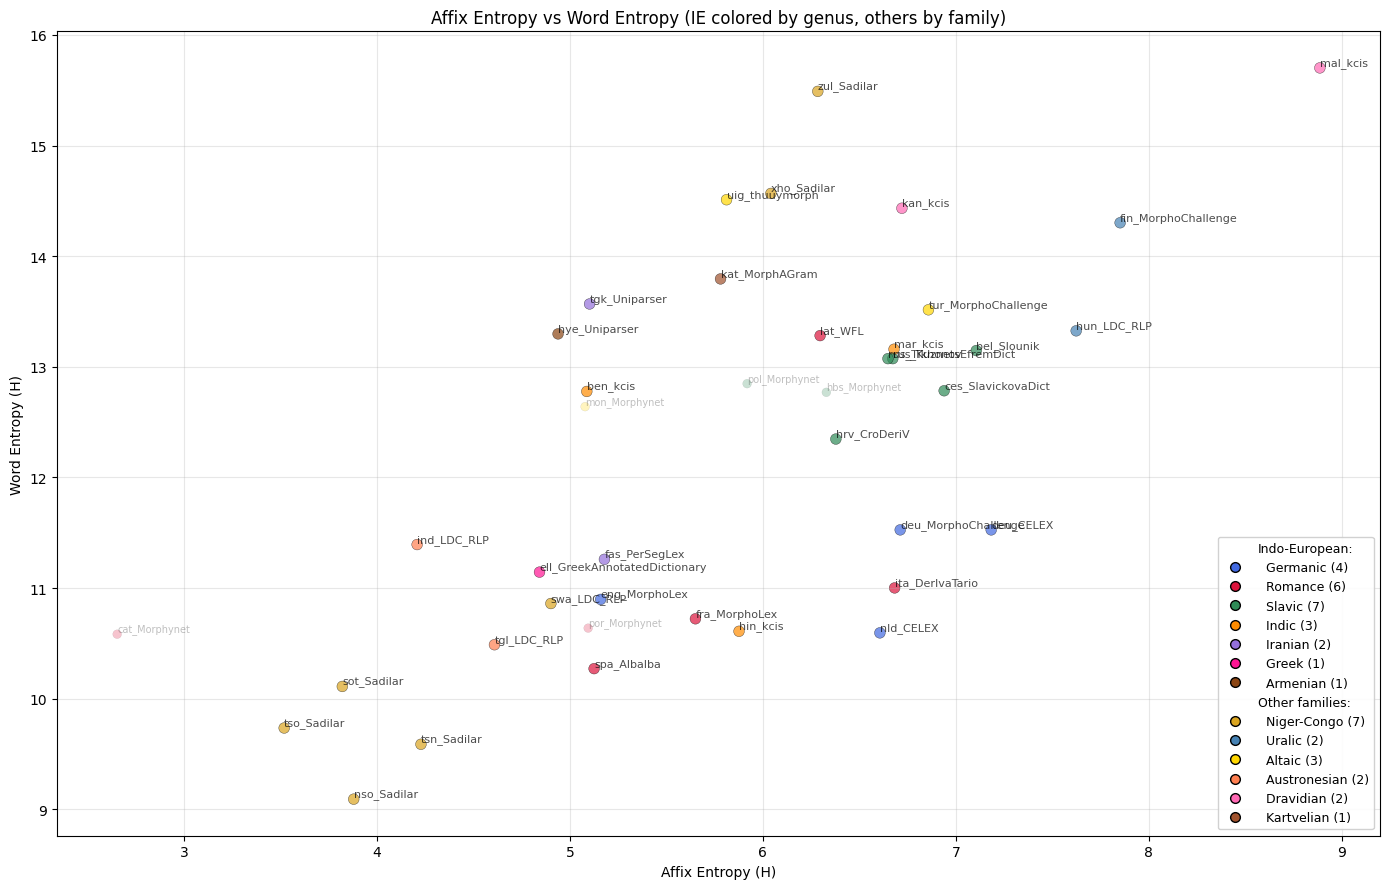

In [49]:
# Affix Entropy vs Word Entropy
fig, ax = plt.subplots(figsize=(14, 9))

ax.scatter(dfm_main["affix_entropy"], dfm_main["word_entropy"], s=60, alpha=0.7,
           c=dfm_main["color"], edgecolors="k", linewidths=0.3)
ax.scatter(dfm_morph["affix_entropy"], dfm_morph["word_entropy"], s=40, alpha=0.25,
           c=dfm_morph["color"], edgecolors="k", linewidths=0.15)

for _, row in dfm_main.iterrows():
    ax.annotate(row["label"], (row["affix_entropy"], row["word_entropy"]),
                fontsize=8, alpha=0.7, ha="left", va="bottom")
for _, row in dfm_morph.iterrows():
    ax.annotate(row["label"], (row["affix_entropy"], row["word_entropy"]),
                fontsize=7, alpha=0.25, ha="left", va="bottom")

ax.set_xlabel("Affix Entropy (H)")
ax.set_ylabel("Word Entropy (H)")
ax.set_title("Affix Entropy vs Word Entropy (IE colored by genus, others by family)")
ax.grid(alpha=0.3)

handles = lm.build_color_legend(dfm, counts=True)
ax.legend(handles=handles, loc="lower right", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

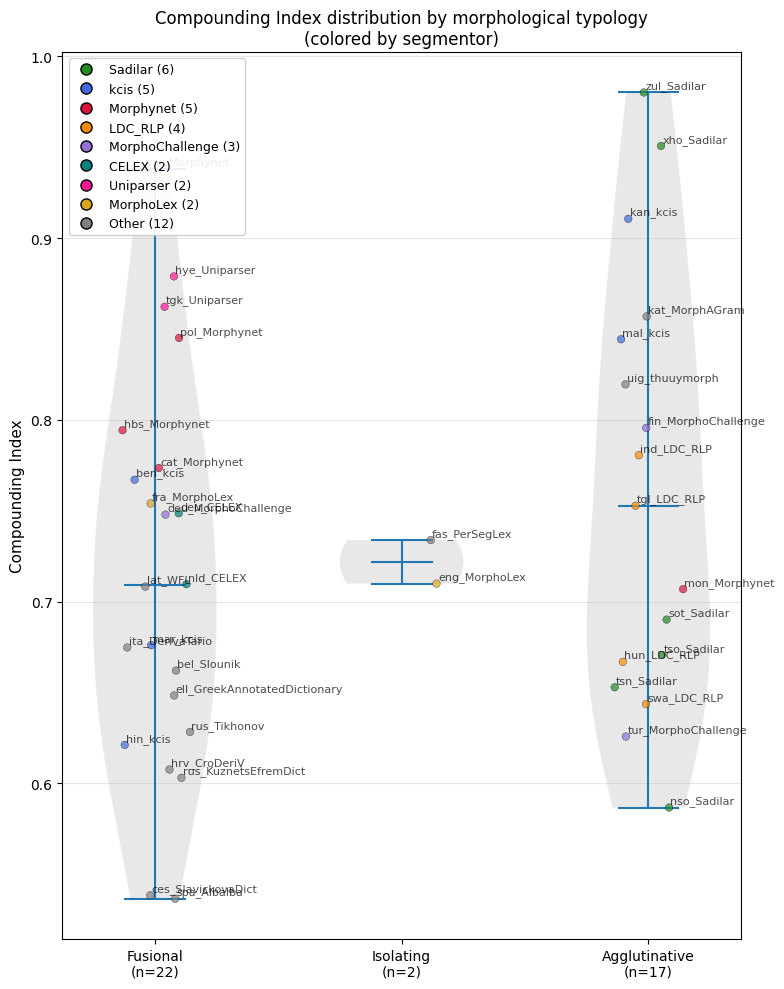


Median compounding index by typology:
typology
Fusional         0.708879
Isolating        0.721843
Agglutinative    0.752740

Mean compounding index by typology:
typology
Fusional         0.714684
Isolating        0.721843
Agglutinative    0.760836


In [50]:
# Violin plot: Compounding Index by morphological typology (colored by segmentor)
df_typo = dfm.dropna(subset=["compounding_index", "typology"]).copy()

def get_seg_color(seg):
    return lm.SEGMENTOR_COLORS.get(seg, "gray")

df_typo["seg_color"] = df_typo["segmentor"].apply(get_seg_color)

# Order by median compounding index
typo_order = df_typo.groupby("typology")["compounding_index"].median().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(8, 10))

data_by_typo = [df_typo[df_typo["typology"] == t]["compounding_index"].values for t in typo_order]
counts = [len(d) for d in data_by_typo]

parts = ax.violinplot(data_by_typo, vert=True, showmedians=True, showextrema=True)

for pc in parts["bodies"]:
    pc.set_facecolor("lightgray")
    pc.set_alpha(0.5)

# Overlay individual points (jittered) colored by segmentor, with labels
rng = np.random.default_rng(42)
for i, t in enumerate(typo_order):
    subset = df_typo[df_typo["typology"] == t].sort_values("compounding_index")
    jitter = rng.uniform(-0.15, 0.15, size=len(subset))
    y_vals = subset["compounding_index"].values
    x_vals = (i + 1) + jitter
    ax.scatter(x_vals, y_vals, s=30, alpha=0.7, c=subset["seg_color"].values,
               edgecolors="k", linewidths=0.3, zorder=3)
    for x, y, name in zip(x_vals, y_vals, subset["label"].values):
        ax.annotate(name, (x, y), fontsize=8, alpha=0.7, ha="left", va="bottom",
                    xytext=(1, 1), textcoords="offset points")

labels = [f"{t}\n(n={c})" for t, c in zip(typo_order, counts)]
ax.set_xticks(range(1, len(typo_order) + 1))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Compounding Index", fontsize=11)
ax.set_title("Compounding Index distribution by morphological typology\n(colored by segmentor)")
ax.grid(axis="y", alpha=0.3)

# Legend for segmentors
seg_in_data = df_typo["segmentor"].value_counts()
handles = []
for seg, color in lm.SEGMENTOR_COLORS.items():
    if seg in seg_in_data.index:
        handles.append(Line2D([0], [0], marker="o", color="w", markerfacecolor=color,
                               markeredgecolor="k", markersize=8, label=f"{seg} ({seg_in_data[seg]})"))
n_other = (df_typo["seg_color"] == "gray").sum()
if n_other:
    handles.append(Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
                           markeredgecolor="k", markersize=8, label=f"Other ({n_other})"))
ax.legend(handles=handles, loc="upper left", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

print("\nMedian compounding index by typology:")
print(df_typo.groupby("typology")["compounding_index"].median().sort_values().to_string())
print("\nMean compounding index by typology:")
print(df_typo.groupby("typology")["compounding_index"].mean().sort_values().to_string())

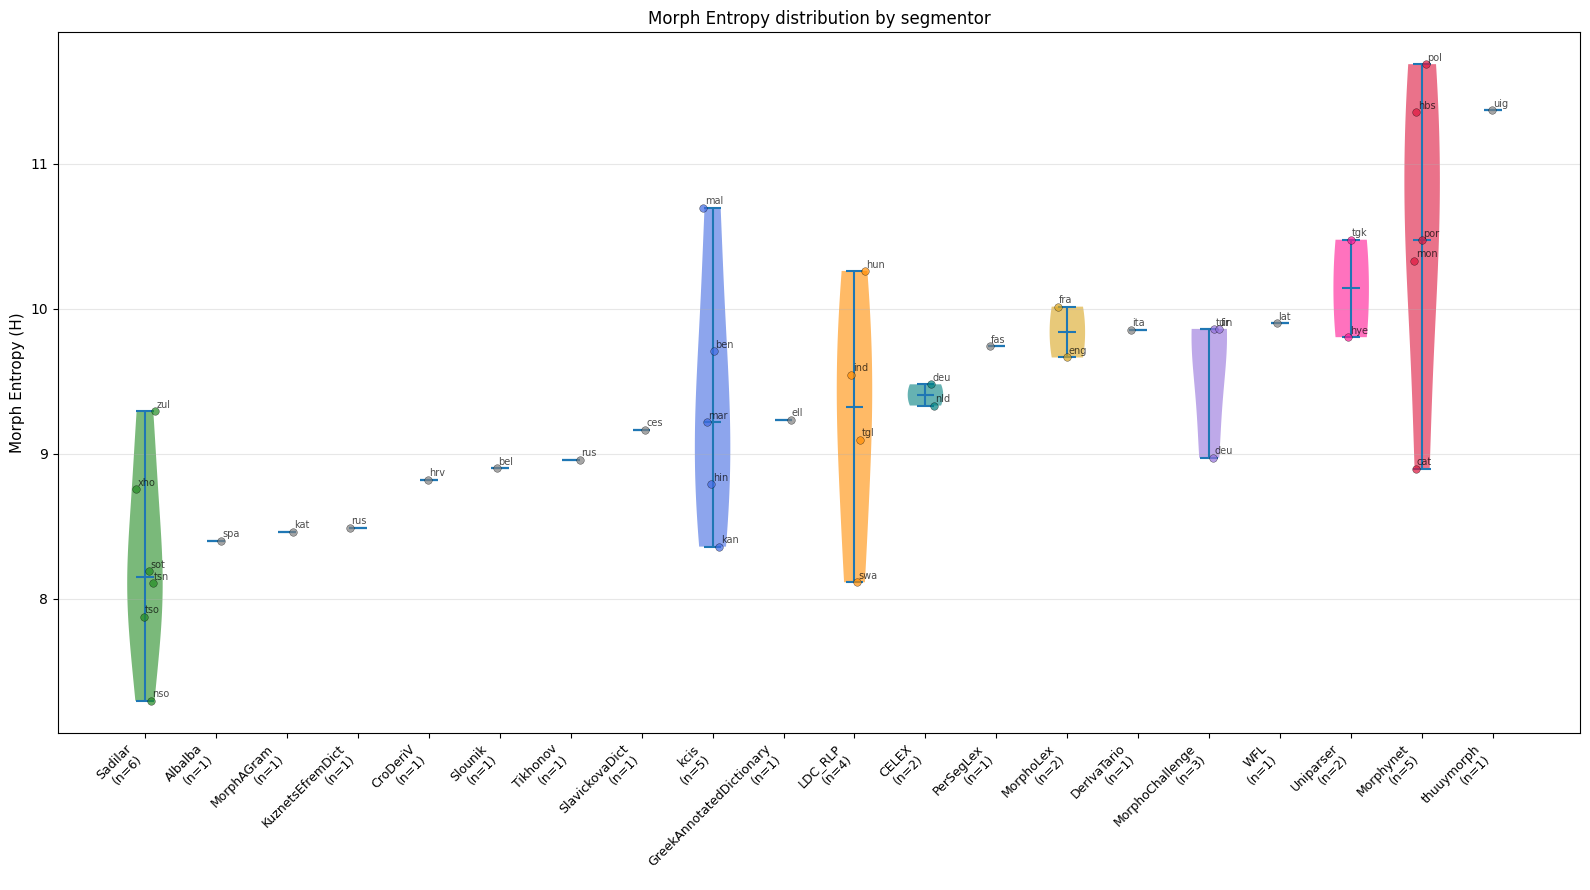


Median morph entropy by segmentor:
segmentor
Sadilar                      8.149188
Albalba                      8.399917
MorphAGram                   8.462773
KuznetsEfremDict             8.489584
CroDeriV                     8.820421
Slounik                      8.901330
Tikhonov                     8.960018
SlavickovaDict               9.165359
kcis                         9.216240
GreekAnnotatedDictionary     9.236220
LDC_RLP                      9.321501
CELEX                        9.406198
PerSegLex                    9.741639
MorphoLex                    9.839831
DerIvaTario                  9.855844
MorphoChallenge              9.860075
WFL                          9.899674
Uniparser                   10.140694
Morphynet                   10.474489
thuuymorph                  11.368893

Mean morph entropy by segmentor:
segmentor
Sadilar                      8.253709
Albalba                      8.399917
MorphAGram                   8.462773
KuznetsEfremDict             8.48958

In [51]:
# Violin plot: Morph Entropy by segmentor
seg_order = dfm.groupby("segmentor")["morph_entropy"].median().sort_values().index.tolist()

num_segs = len(seg_order)
fig, ax = plt.subplots(figsize=(max(8, num_segs * 0.8), 9))

data_by_seg = [dfm[dfm["segmentor"] == s]["morph_entropy"].values for s in seg_order]
counts = [len(d) for d in data_by_seg]

parts = ax.violinplot(data_by_seg, vert=True, showmedians=True, showextrema=True)

for i, (pc, s) in enumerate(zip(parts["bodies"], seg_order)):
    pc.set_facecolor(lm.SEGMENTOR_COLORS.get(s, "gray"))
    pc.set_alpha(0.6)

# Overlay individual points (jittered) with labels
rng = np.random.default_rng(42)
for i, s in enumerate(seg_order):
    subset = dfm[dfm["segmentor"] == s].sort_values("morph_entropy")
    jitter = rng.uniform(-0.15, 0.15, size=len(subset))
    y_vals = subset["morph_entropy"].values
    x_vals = (i + 1) + jitter
    color = lm.SEGMENTOR_COLORS.get(s, "gray")
    ax.scatter(x_vals, y_vals, s=30, alpha=0.7, c=color,
               edgecolors="k", linewidths=0.3, zorder=3)
    for x, y, name in zip(x_vals, y_vals, subset["lang"].values):
        ax.annotate(name, (x, y), fontsize=7, alpha=0.7, ha="left", va="bottom",
                    xytext=(1, 1), textcoords="offset points")

labels = [f"{s}\n(n={c})" for s, c in zip(seg_order, counts)]
ax.set_xticks(range(1, len(seg_order) + 1))
ax.set_xticklabels(labels, fontsize=9, rotation=45, ha="right")
ax.set_ylabel("Morph Entropy (H)", fontsize=11)
ax.set_title("Morph Entropy distribution by segmentor")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nMedian morph entropy by segmentor:")
print(dfm.groupby("segmentor")["morph_entropy"].median().sort_values().to_string())
print("\nMean morph entropy by segmentor:")
print(dfm.groupby("segmentor")["morph_entropy"].mean().sort_values().to_string())

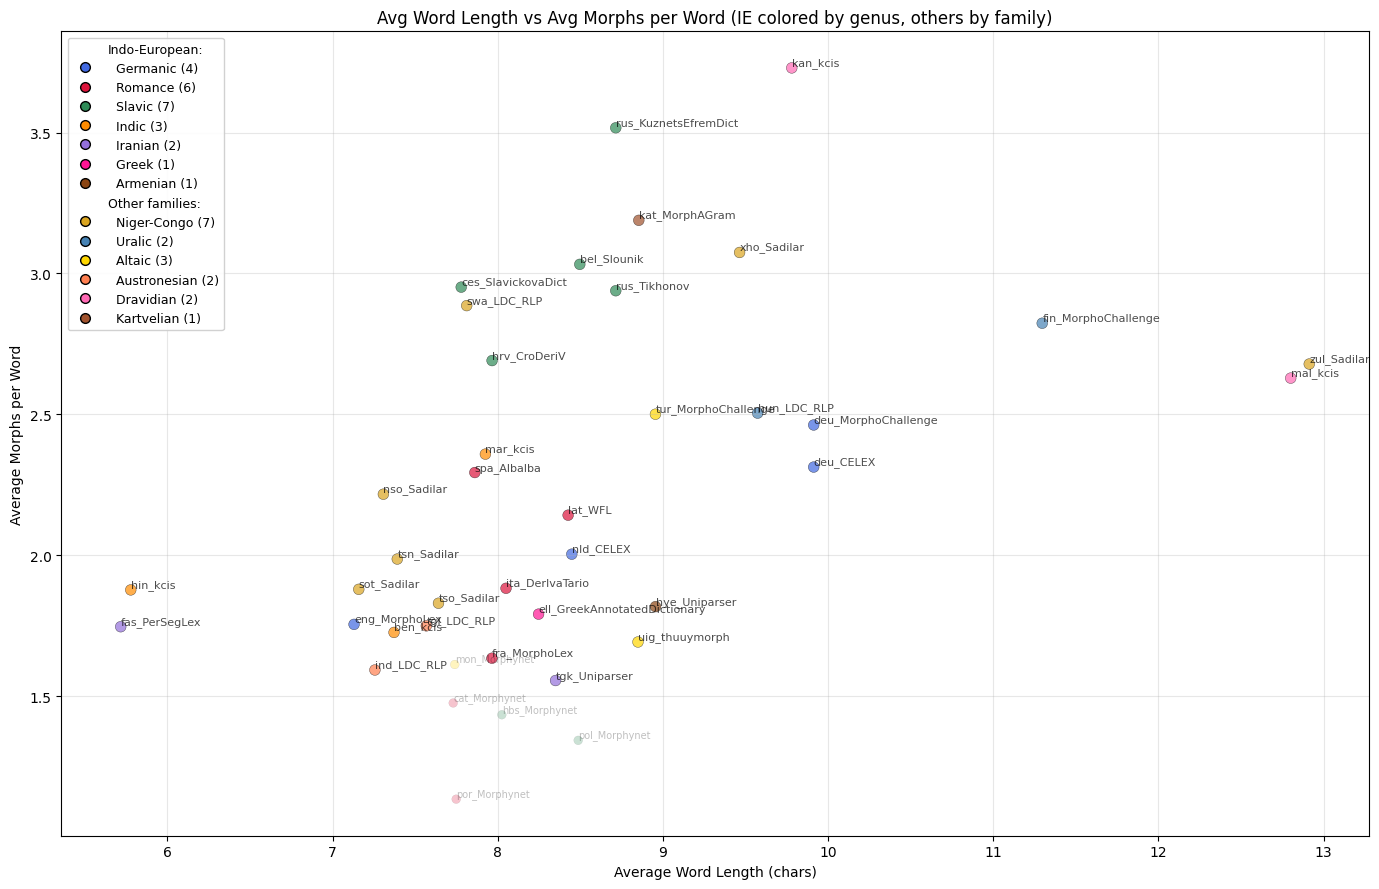

In [52]:
# Avg Word Length vs Avg Morphs per Word
fig, ax = plt.subplots(figsize=(14, 9))

ax.scatter(dfm_main["word_avg_length"], dfm_main["avg_morphs_per_word"], s=60, alpha=0.7,
           c=dfm_main["color"], edgecolors="k", linewidths=0.3)
ax.scatter(dfm_morph["word_avg_length"], dfm_morph["avg_morphs_per_word"], s=40, alpha=0.25,
           c=dfm_morph["color"], edgecolors="k", linewidths=0.15)

for _, row in dfm_main.iterrows():
    ax.annotate(row["label"], (row["word_avg_length"], row["avg_morphs_per_word"]),
                fontsize=8, alpha=0.7, ha="left", va="bottom")
for _, row in dfm_morph.iterrows():
    ax.annotate(row["label"], (row["word_avg_length"], row["avg_morphs_per_word"]),
                fontsize=7, alpha=0.25, ha="left", va="bottom")

ax.set_xlabel("Average Word Length (chars)")
ax.set_ylabel("Average Morphs per Word")
ax.set_title("Avg Word Length vs Avg Morphs per Word (IE colored by genus, others by family)")
ax.grid(alpha=0.3)

handles = lm.build_color_legend(dfm, counts=True)
ax.legend(handles=handles, loc="upper left", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

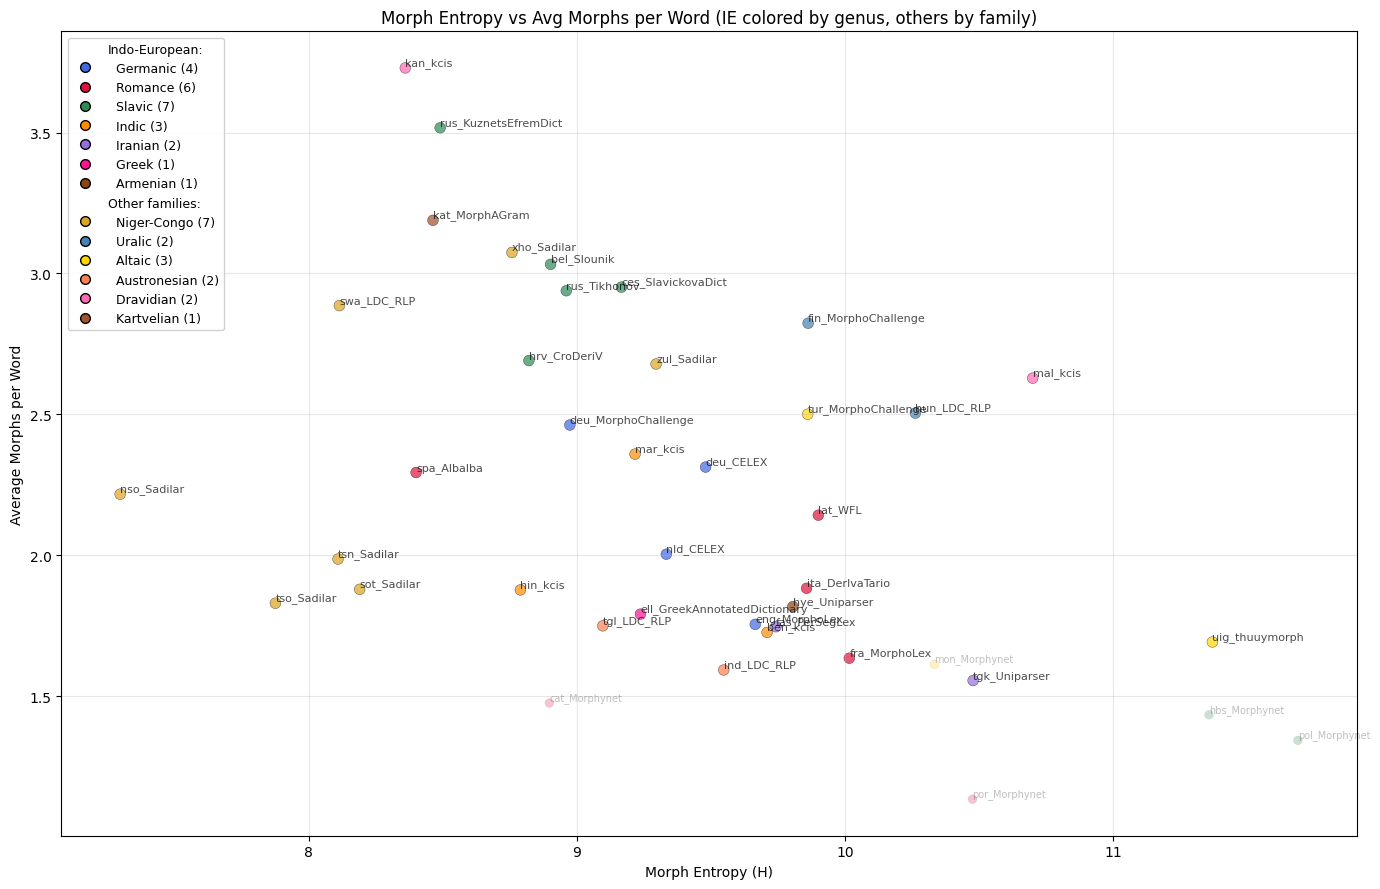

In [53]:
# Morph Entropy vs Avg Morphs per Word
fig, ax = plt.subplots(figsize=(14, 9))

ax.scatter(dfm_main["morph_entropy"], dfm_main["avg_morphs_per_word"], s=60, alpha=0.7,
           c=dfm_main["color"], edgecolors="k", linewidths=0.3)
ax.scatter(dfm_morph["morph_entropy"], dfm_morph["avg_morphs_per_word"], s=40, alpha=0.25,
           c=dfm_morph["color"], edgecolors="k", linewidths=0.15)

for _, row in dfm_main.iterrows():
    ax.annotate(row["label"], (row["morph_entropy"], row["avg_morphs_per_word"]),
                fontsize=8, alpha=0.7, ha="left", va="bottom")
for _, row in dfm_morph.iterrows():
    ax.annotate(row["label"], (row["morph_entropy"], row["avg_morphs_per_word"]),
                fontsize=7, alpha=0.25, ha="left", va="bottom")

ax.set_xlabel("Morph Entropy (H)")
ax.set_ylabel("Average Morphs per Word")
ax.set_title("Morph Entropy vs Avg Morphs per Word (IE colored by genus, others by family)")
ax.grid(alpha=0.3)

handles = lm.build_color_legend(dfm, counts=True)
ax.legend(handles=handles, loc="upper left", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

In [54]:
# Values for deu and rus datasets
cols = ["label", "lang", "word_avg_length", "avg_morphs_per_word", "morph_entropy", "word_entropy", "compounding_index", "affix_entropy"]
subset = dfm[dfm["lang"].isin(["deu", "rus"])][cols]
print(subset.to_string(index=False))

               label lang  word_avg_length  avg_morphs_per_word  morph_entropy  word_entropy  compounding_index  affix_entropy
           deu_CELEX  deu         9.913059             2.312606       9.479398     11.525586           0.748560       7.183655
 deu_MorphoChallenge  deu         9.913059             2.461952       8.973190     11.525586           0.747838       6.712196
rus_KuznetsEfremDict  rus         8.714659             3.516779       8.489584     13.073372           0.602983       6.673555
        rus_Tikhonov  rus         8.714659             2.938498       8.960018     13.073372           0.628241       6.648603


C:\Users\Tonda\AppData\Local\Temp\ipykernel_64776\880971272.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.0)


graph_export: saved morphemes.pdf


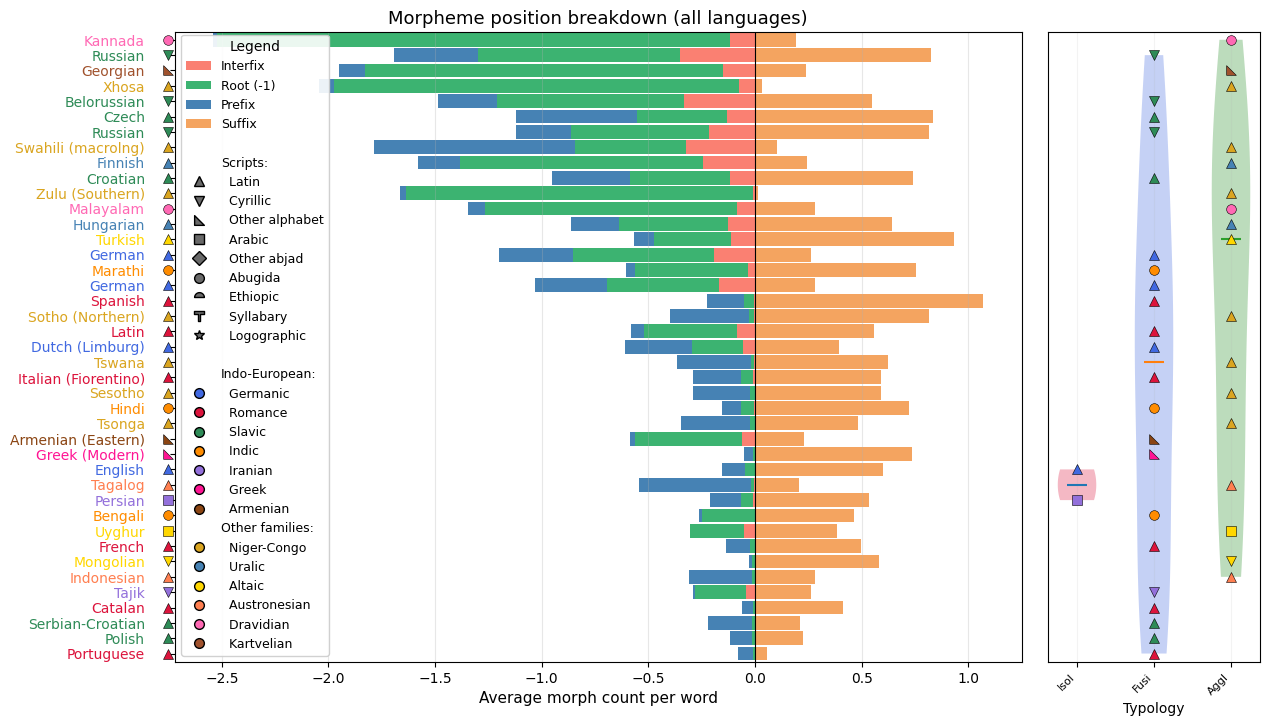

In [55]:
# Morpheme position breakdown (stacked horizontal bar) + typology violin
from matplotlib.gridspec import GridSpec

plot_df = dfm[["label", "language_name", "family", "genus", "script", "typology",
               "avg_morphs_per_word", "avg_roots_per_word",
               "avg_prefixes_per_word", "avg_suffixes_per_word"]].copy()
plot_df["interfix"] = (plot_df["avg_morphs_per_word"]
                       - plot_df["avg_roots_per_word"]
                       - plot_df["avg_prefixes_per_word"]
                       - plot_df["avg_suffixes_per_word"])
plot_df["avg_roots_per_word"] = plot_df["avg_roots_per_word"] - 1
plot_df = plot_df.sort_values("avg_morphs_per_word", ascending=True).reset_index(drop=True)

n = len(plot_df)
y = np.arange(n)

fig = plt.figure(figsize=(14, n * 0.18 + 0.8))
gs = GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)
ax = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharey=ax)

# --- Left: bar chart ---
ax.barh(y, -plot_df["interfix"].values, height=0.9, color="salmon", label="Interfix")
ax.barh(y, -plot_df["avg_roots_per_word"].values,
        left=-plot_df["interfix"].values, height=0.9, color="mediumseagreen", label="Root (-1)")
ax.barh(y, -plot_df["avg_prefixes_per_word"].values,
        left=-plot_df["interfix"].values - plot_df["avg_roots_per_word"].values,
        height=0.9, color="steelblue", label="Prefix")
ax.barh(y, plot_df["avg_suffixes_per_word"].values, height=0.9, color="sandybrown", label="Suffix")

ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(plot_df["language_name"].values, fontsize=10)
lm.add_lang_markers(ax, plot_df)
ax.set_ylim(-0.55, n - 0.5)
ax.set_xlabel("Average morph count per word", fontsize=11)
ax.set_title("Morpheme position breakdown (all languages)", fontsize=13)

spacer = Line2D([], [], linestyle="", marker="", label="")
bar_handles, _ = ax.get_legend_handles_labels()
all_handles = (bar_handles + [spacer]
               + lm.build_script_legend() + [spacer]
               + lm.build_color_legend(plot_df))
ax.legend(handles=all_handles, loc="lower left", fontsize=9, framealpha=0.9, title="Legend")
ax.grid(axis="x", alpha=0.3)

# --- Right: typology vertical violins + language markers ---
typo_cats = [t for t in lm.TYPOLOGY_COLORS.keys() if (plot_df["typology"] == t).any()]
typo_x = {t: i for i, t in enumerate(typo_cats)}

# Vertical violins: each violin shows the distribution of y-positions for that typology
for i, t in enumerate(typo_cats):
    grp = plot_df.loc[plot_df["typology"] == t].index.values.astype(float)
    if len(grp) >= 2:
        parts = ax2.violinplot([grp], positions=[i], vert=True, showmedians=True, showextrema=False)
        for pc in parts["bodies"]:
            pc.set_facecolor(lm.TYPOLOGY_COLORS[t])
            pc.set_alpha(0.3)

# Plot individual language markers (same script marker + color as left graph)
for idx, row in plot_df.iterrows():
    t = row["typology"]
    if t in typo_x:
        c = lm.get_color(row)
        m = lm.get_marker(row)
        ax2.plot(typo_x[t], idx, marker=m, color=c, markersize=7,
                 markeredgecolor="k", markeredgewidth=0.4, linestyle="None", zorder=3)

ax2.set_xticks(range(len(typo_cats)))
ax2.set_xticklabels([t[:4] for t in typo_cats], fontsize=8, rotation=45, ha="right")
ax2.set_xlabel("Typology", fontsize=10)
ax2.tick_params(left=False, labelleft=False)
ax2.set_ylim(-0.55, n - 0.5)
ax2.grid(axis="x", alpha=0.15)

plt.tight_layout(pad=0.0)
graph_export.save("morphemes", fig)
plt.show()

C:\Users\Tonda\AppData\Local\Temp\ipykernel_64776\1827841707.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.0)


graph_export: saved compounding.pdf


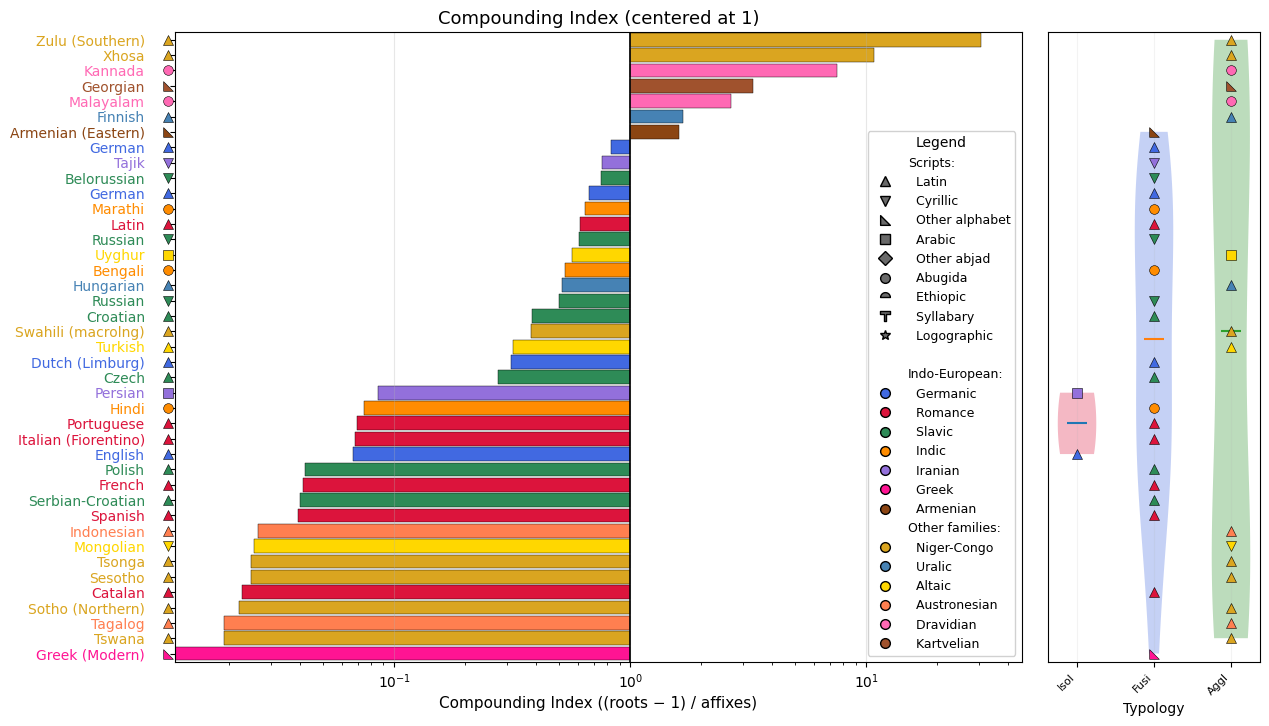

In [56]:
# Compounding Index = (avg_roots_per_word - 1) / avg_affixes_per_word
# Bar chart (log scale, centered at 1) + typology violins on right

plot_aff = dfm[["label", "language_name", "family", "genus", "script", "typology",
                "avg_affixes_per_word", "avg_roots_per_word"]].copy()
plot_aff["compounding_score"] = (plot_aff["avg_roots_per_word"] - 1) / plot_aff["avg_affixes_per_word"]
plot_aff = plot_aff.sort_values("compounding_score", ascending=True).reset_index(drop=True)

n = len(plot_aff)
y = np.arange(n)

fig = plt.figure(figsize=(14, n * 0.18 + 0.8))
gs = GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)
ax = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharey=ax)

# --- Left: bar chart centered at 1 on log scale ---
scores = plot_aff["compounding_score"].values
colors = [lm.get_color(row) for _, row in plot_aff.iterrows()]

# Bars from 1 to score (works on log scale)
widths = scores - 1
lefts = np.where(scores >= 1, 1, scores)
bar_widths = np.abs(widths)
ax.barh(y, bar_widths, left=lefts, height=0.9, color=colors, edgecolor="k", linewidth=0.3)
ax.axvline(1, color="black", linewidth=1.2)
ax.set_xscale("log")

ax.set_yticks(y)
ax.set_yticklabels(plot_aff["language_name"].values, fontsize=10)
lm.add_lang_markers(ax, plot_aff)
ax.set_ylim(-0.55, n - 0.5)
ax.set_xlabel("Compounding Index ((roots − 1) / affixes)", fontsize=11)
ax.set_title("Compounding Index (centered at 1)", fontsize=13)

spacer = Line2D([], [], linestyle="", marker="", label="")
all_handles = (lm.build_script_legend() + [spacer]
               + lm.build_color_legend(plot_aff))
ax.legend(handles=all_handles, loc="lower right", fontsize=9, framealpha=0.9, title="Legend")
ax.grid(axis="x", alpha=0.3)

# --- Right: typology vertical violins + language markers ---
typo_cats = [t for t in lm.TYPOLOGY_COLORS.keys() if (plot_aff["typology"] == t).any()]
typo_x = {t: i for i, t in enumerate(typo_cats)}

for i, t in enumerate(typo_cats):
    grp = plot_aff.loc[plot_aff["typology"] == t].index.values.astype(float)
    if len(grp) >= 2:
        parts = ax2.violinplot([grp], positions=[i], vert=True, showmedians=True, showextrema=False)
        for pc in parts["bodies"]:
            pc.set_facecolor(lm.TYPOLOGY_COLORS[t])
            pc.set_alpha(0.3)

for idx, row in plot_aff.iterrows():
    t = row["typology"]
    if t in typo_x:
        c = lm.get_color(row)
        m = lm.get_marker(row)
        ax2.plot(typo_x[t], idx, marker=m, color=c, markersize=7,
                 markeredgecolor="k", markeredgewidth=0.4, linestyle="None", zorder=3)

ax2.set_xticks(range(len(typo_cats)))
ax2.set_xticklabels([t[:4] for t in typo_cats], fontsize=8, rotation=45, ha="right")
ax2.set_xlabel("Typology", fontsize=10)
ax2.tick_params(left=False, labelleft=False)
ax2.set_ylim(-0.55, n - 0.5)
ax2.grid(axis="x", alpha=0.15)

plt.tight_layout(pad=0.0)
graph_export.save("compounding", fig)
plt.show()

C:\Users\Tonda\AppData\Local\Temp\ipykernel_64776\3665795176.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.0)


graph_export: saved affix_deviation.pdf


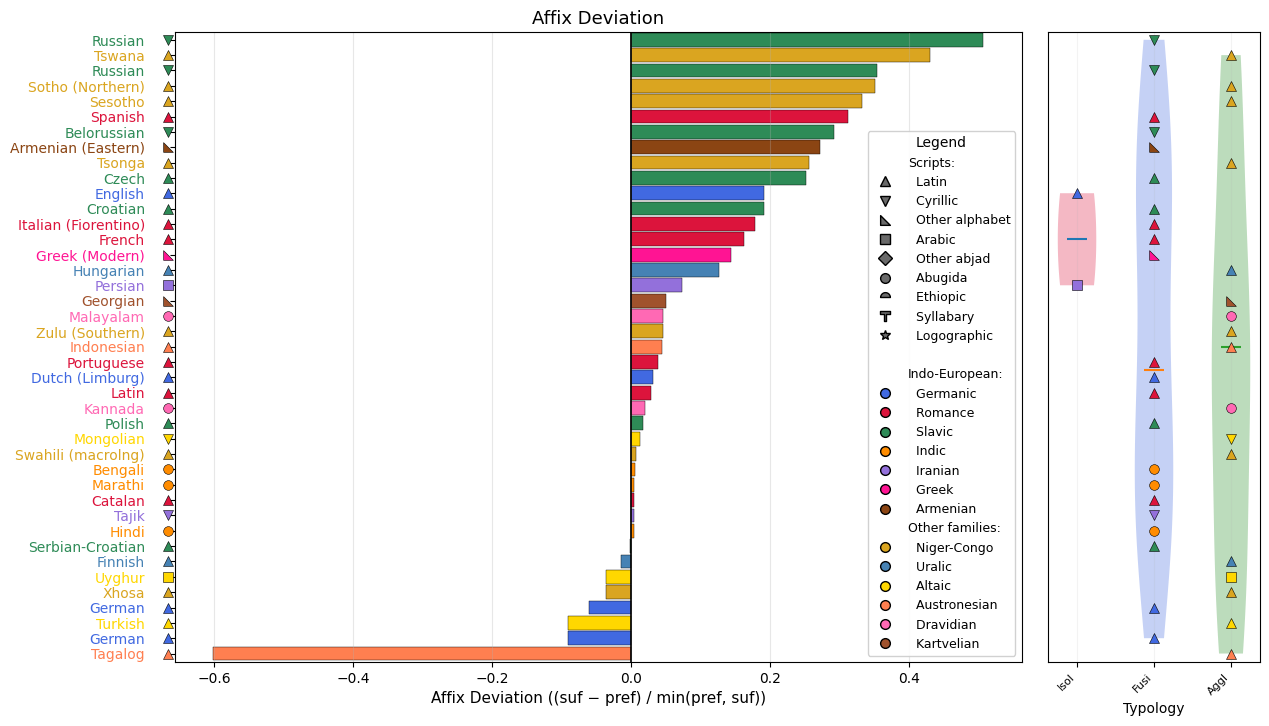

In [57]:
plot_dev = dfm[["label", "language_name", "family", "genus", "script", "typology",
                "affix_deviation"]].dropna(subset=["affix_deviation"]).copy()
plot_dev = plot_dev.sort_values("affix_deviation", ascending=True).reset_index(drop=True)

n = len(plot_dev)
y = np.arange(n)

fig = plt.figure(figsize=(14, n * 0.18 + 0.8))
gs = GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)
ax = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharey=ax)

devs = plot_dev["affix_deviation"].values
colors = [lm.get_color(row) for _, row in plot_dev.iterrows()]

ax.barh(y, devs, height=0.9, color=colors, edgecolor="k", linewidth=0.3)
ax.axvline(0, color="black", linewidth=1.2)

ax.set_yticks(y)
ax.set_yticklabels(plot_dev["language_name"].values, fontsize=10)
lm.add_lang_markers(ax, plot_dev)
ax.set_ylim(-0.55, n - 0.5)
ax.set_xlabel("Affix Deviation ((suf − pref) / min(pref, suf))", fontsize=11)
ax.set_title("Affix Deviation", fontsize=13)

spacer = Line2D([], [], linestyle="", marker="", label="")
all_handles = (lm.build_script_legend() + [spacer]
               + lm.build_color_legend(plot_dev))
ax.legend(handles=all_handles, loc="lower right", fontsize=9, framealpha=0.9, title="Legend")
ax.grid(axis="x", alpha=0.3)

# --- Right: typology vertical violins + language markers ---
typo_cats = [t for t in lm.TYPOLOGY_COLORS.keys() if (plot_dev["typology"] == t).any()]
typo_x = {t: i for i, t in enumerate(typo_cats)}

for i, t in enumerate(typo_cats):
    grp = plot_dev.loc[plot_dev["typology"] == t].index.values.astype(float)
    if len(grp) >= 2:
        parts = ax2.violinplot([grp], positions=[i], vert=True, showmedians=True, showextrema=False)
        for pc in parts["bodies"]:
            pc.set_facecolor(lm.TYPOLOGY_COLORS[t])
            pc.set_alpha(0.3)

for idx, row in plot_dev.iterrows():
    t = row["typology"]
    if t in typo_x:
        c = lm.get_color(row)
        m = lm.get_marker(row)
        ax2.plot(typo_x[t], idx, marker=m, color=c, markersize=7,
                 markeredgecolor="k", markeredgewidth=0.4, linestyle="None", zorder=3)

ax2.set_xticks(range(len(typo_cats)))
ax2.set_xticklabels([t[:4] for t in typo_cats], fontsize=8, rotation=45, ha="right")
ax2.set_xlabel("Typology", fontsize=10)
ax2.tick_params(left=False, labelleft=False)
ax2.set_ylim(-0.55, n - 0.5)
ax2.grid(axis="x", alpha=0.15)

plt.tight_layout(pad=0.0)
graph_export.save("affix_deviation", fig)
plt.show()

graph_export: saved morphemes_weighted.pdf


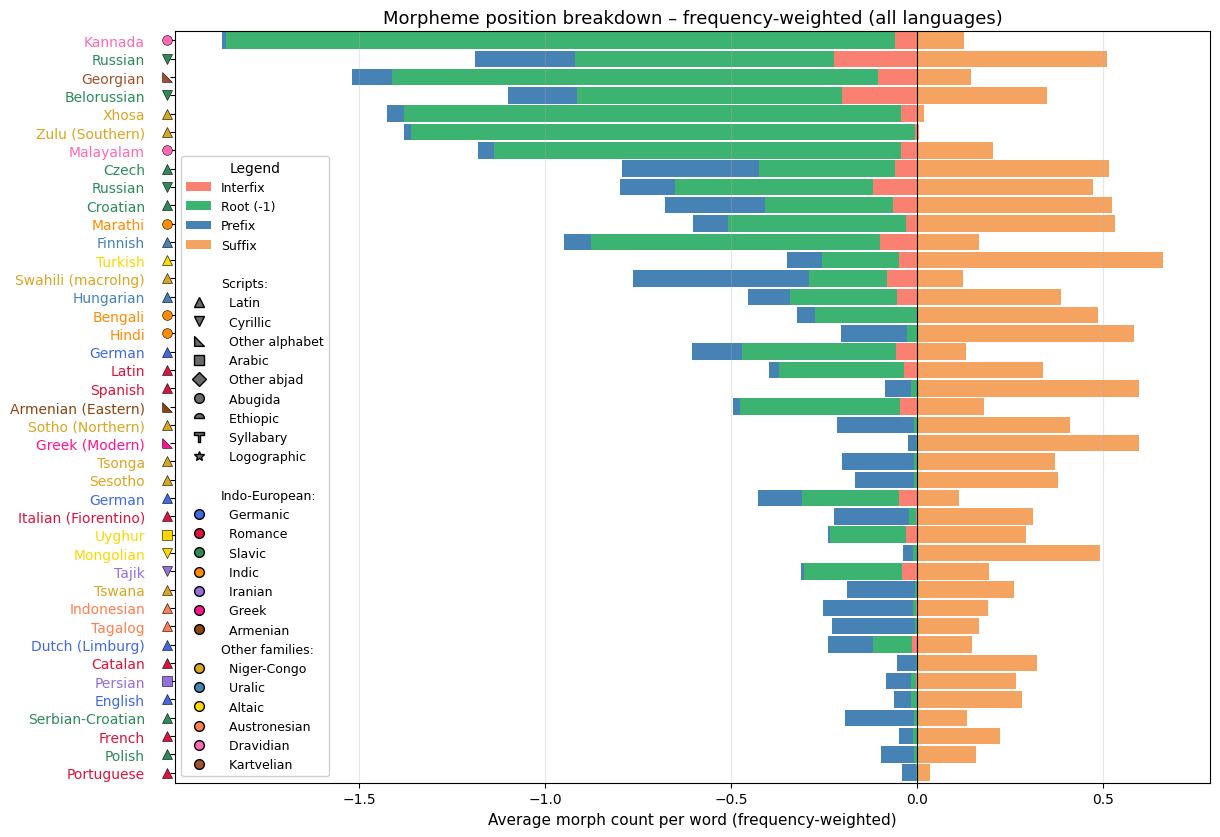

In [58]:
# Morpheme position breakdown – frequency-weighted (stacked horizontal bar)
plot_df_w = dfm[["label", "language_name", "family", "genus", "script",
                 "avg_morphs_per_word_weighted", "avg_roots_per_word_weighted",
                 "avg_prefixes_per_word_weighted", "avg_suffixes_per_word_weighted"]].copy()
plot_df_w["interfix"] = (plot_df_w["avg_morphs_per_word_weighted"]
                         - plot_df_w["avg_roots_per_word_weighted"]
                         - plot_df_w["avg_prefixes_per_word_weighted"]
                         - plot_df_w["avg_suffixes_per_word_weighted"])
plot_df_w["avg_roots_per_word_weighted"] = plot_df_w["avg_roots_per_word_weighted"] - 1
plot_df_w = plot_df_w.sort_values("avg_morphs_per_word_weighted", ascending=True)

n = len(plot_df_w)
y = np.arange(n)

fig, ax = plt.subplots(figsize=(12, n * 0.18 + 0.8))

# Left of zero: interfix → root → prefix
ax.barh(y, -plot_df_w["interfix"].values, height=0.9, color="salmon", label="Interfix")
ax.barh(y, -plot_df_w["avg_roots_per_word_weighted"].values,
        left=-plot_df_w["interfix"].values, height=0.9, color="mediumseagreen", label="Root (-1)")
ax.barh(y, -plot_df_w["avg_prefixes_per_word_weighted"].values,
        left=-plot_df_w["interfix"].values - plot_df_w["avg_roots_per_word_weighted"].values,
        height=0.9, color="steelblue", label="Prefix")
# Right of zero: suffix
ax.barh(y, plot_df_w["avg_suffixes_per_word_weighted"].values, height=0.9, color="sandybrown", label="Suffix")

ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(plot_df_w["language_name"].values, fontsize=10)

# Colored script markers next to each label
lm.add_lang_markers(ax, plot_df_w)

ax.set_ylim(-0.55, n - 0.5)
ax.set_xlabel("Average morph count per word (frequency-weighted)", fontsize=11)
ax.set_title("Morpheme position breakdown – frequency-weighted (all languages)", fontsize=13)

# Legend: bar parts + script shapes + color key
spacer = Line2D([], [], linestyle="", marker="", label="")
bar_handles, _ = ax.get_legend_handles_labels()
all_handles = (bar_handles + [spacer]
               + lm.build_script_legend() + [spacer]
               + lm.build_color_legend(plot_df_w))
ax.legend(handles=all_handles, loc="lower left", fontsize=9, framealpha=0.9, title="Legend")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout(pad=0.0)
graph_export.save("morphemes_weighted", fig)
plt.show()

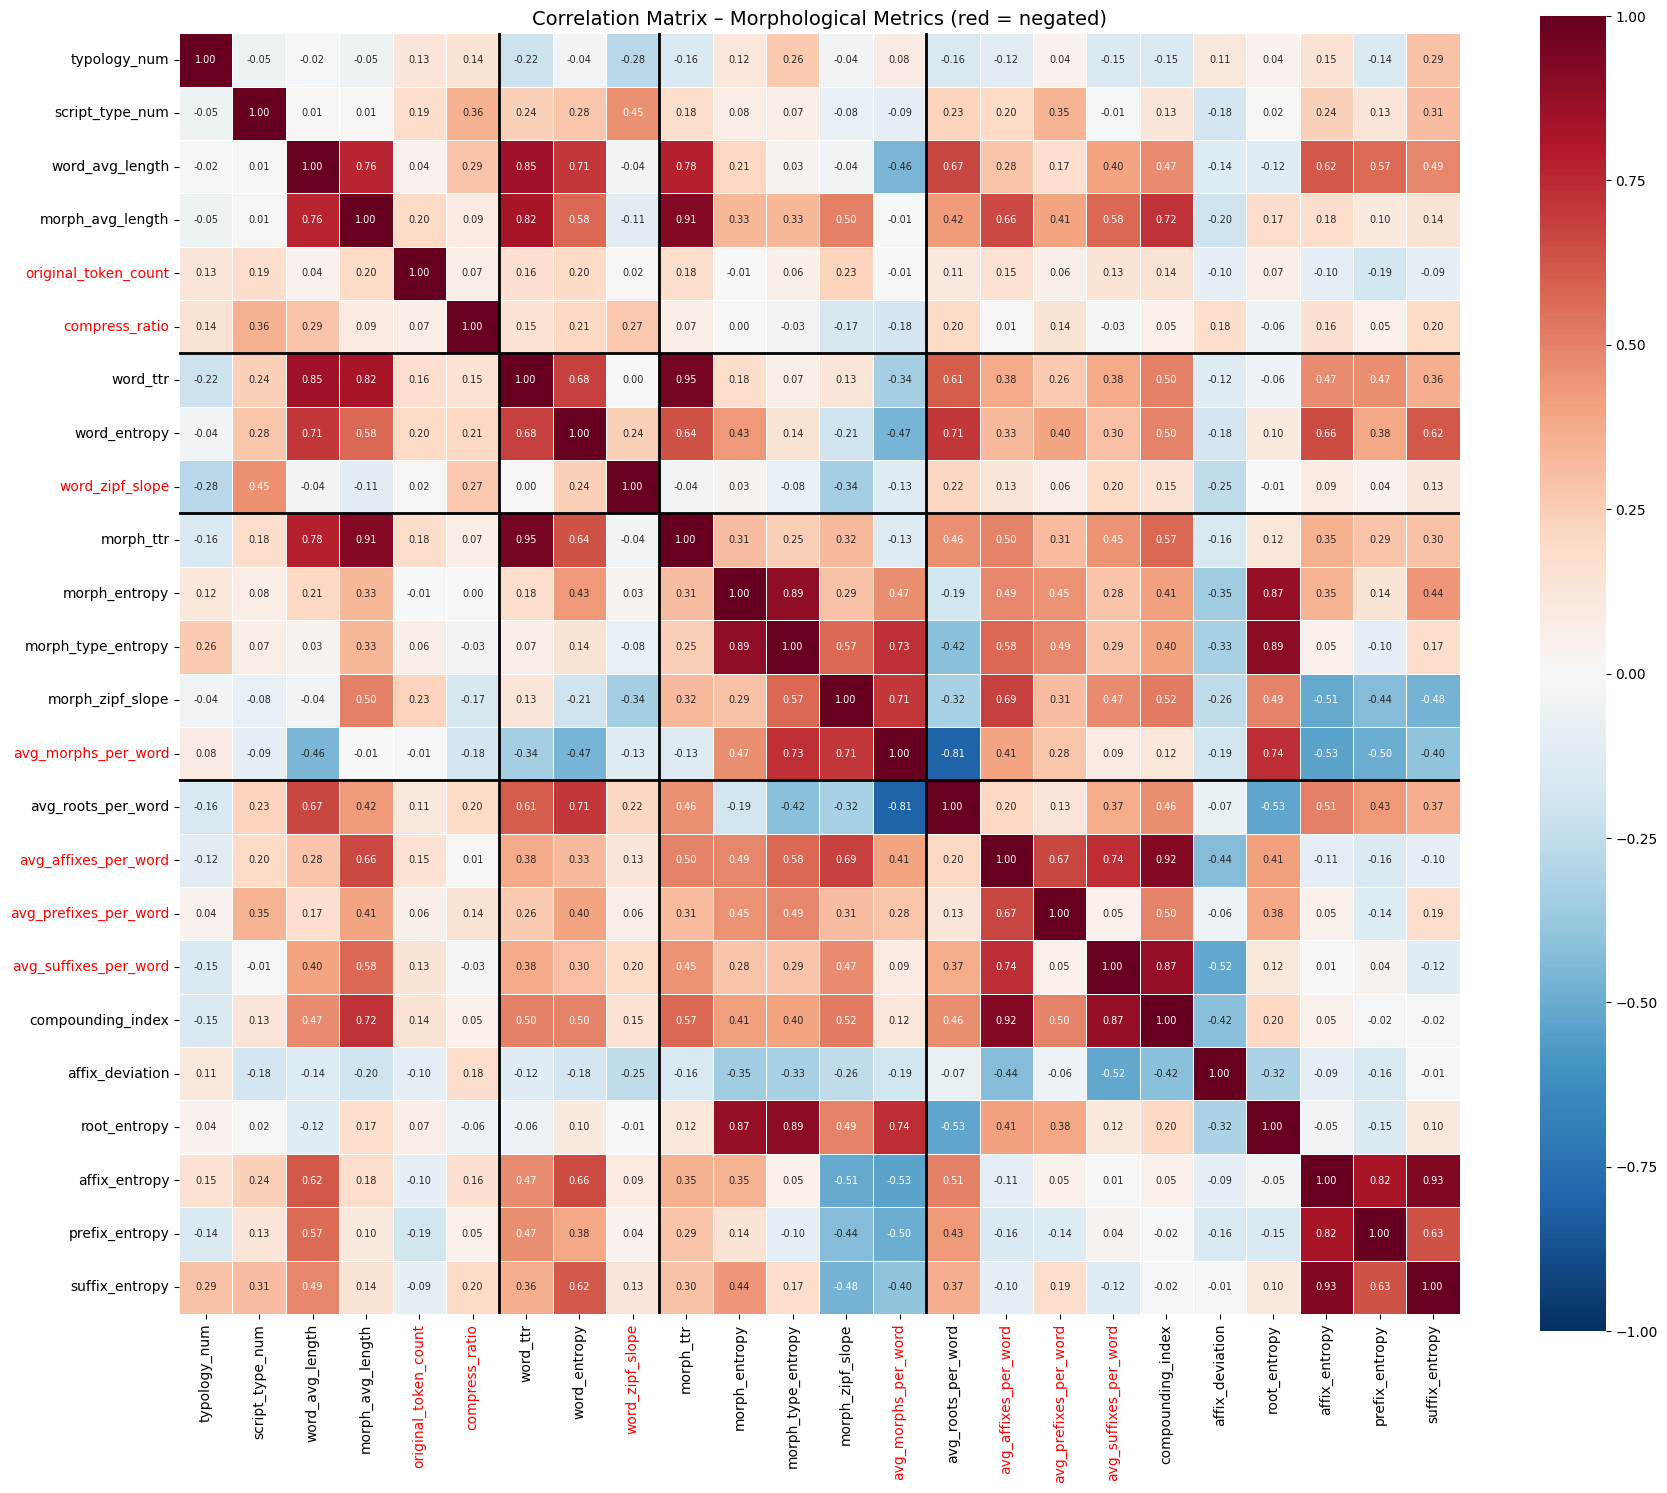

In [59]:
# Correlation matrix of all thesis metrics
import seaborn as sns

metrics = [
    # General (6)
    "typology_num", "script_type_num", "word_avg_length", "morph_avg_length", "original_token_count", "compress_ratio",
    # Word-level (3)
    "word_ttr", "word_entropy", "word_zipf_slope",
    # Morph-level (5)
    "morph_ttr", "morph_entropy", "morph_type_entropy", "morph_zipf_slope", "avg_morphs_per_word",
    # Affix / root / compounding (10)
    "avg_roots_per_word", "avg_affixes_per_word",
    "avg_prefixes_per_word", "avg_suffixes_per_word",
    "compounding_index", "affix_deviation",
    "root_entropy", "affix_entropy",
    "prefix_entropy", "suffix_entropy",
]

# Metrics to negate (-x) so higher = more isolating
negate_metrics = [
    "original_token_count", "compress_ratio",
    "word_zipf_slope",
    "avg_morphs_per_word",
    "avg_affixes_per_word", "avg_prefixes_per_word", "avg_suffixes_per_word",
]

# Build correlation dataframe with negations
corr_df = dfm[metrics].copy()
for m in negate_metrics:
    corr_df[m] = -corr_df[m]

corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r",
    vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5,
    annot_kws={"size": 7},
    ax=ax,
)

# Black lines between categories (boundaries at indices 6, 9, 14)
for boundary in [6, 9, 14]:
    ax.axhline(y=boundary, color="black", linewidth=2)
    ax.axvline(x=boundary, color="black", linewidth=2)

# Color negated metric labels red
for label in ax.get_xticklabels():
    if label.get_text() in negate_metrics:
        label.set_color("red")
for label in ax.get_yticklabels():
    if label.get_text() in negate_metrics:
        label.set_color("red")

ax.set_title("Correlation Matrix – Morphological Metrics (red = negated)", fontsize=14)
plt.tight_layout()
plt.show()